<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/05_Assignment_Time_Series_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Due 1st May 2026 Midnight
#### For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
#### Please make sure that you are not simply copying each other's code, but rather striving to understand each other's work and learn from it.
#### Additionally, please provide the R code at the end of your solution and include R commands along with R outputs. This will help to describe your solutions more clearly.

# Section 0: Parvovirus cases

* In this section you will re-run the code demonstrated during time series lecture.
* The assingment will then proceed to further with an aim to create an ARIMA model using rainfall data as predictor.

In [1]:
install.packages(c("forecast","tseries","lubridate","ggthemes"))
library(forecast); library(tseries); library(lubridate)
library(ggthemes); library(plyr); library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘quadprog’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




ERROR: Error in library(plyr): there is no package called ‘plyr’


In [2]:
install.packages("plyr")
library(plyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



For the purposes of this assignment you will need following **new packages* along with other packages that you use regularly
<br/><br/>
`forecast`, `tseries`, `lubridate`, `ggthemes`

In [3]:
ParvoD <- read.csv("/content/Parvo_TS_clean.csv")

#### Save Case.Date to Date in a new column, with as.Date format

In [4]:
ParvoD$Date = as.Date(ParvoD$Case.Date, "%d/%m/%Y")


#### Add columns that are by week or month

In [5]:
ParvoD$byWeek = cut(ParvoD$Date, breaks="1 week")
ParvoD$byMonth = cut(ParvoD$Date, breaks="1 month")

#### Aggregate data by Month

In [6]:
ParvoM= ddply(ParvoD, c("byMonth"), summarise,
                     Cases = sum(Cases),
                     Events = sum(Events))
ParvoM$byMonth <-  as.Date(ParvoM$byMonth, format = "%Y-%m-%d")
head(ParvoM)

,byMonth,Cases,Events
,<date>,<int>,<int>
1,2009-10-01,9,9
2,2009-11-01,9,9
3,2009-12-01,21,18
4,2010-01-01,49,45
5,2010-02-01,66,62
6,2010-03-01,66,60


## Plotting Time Series

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


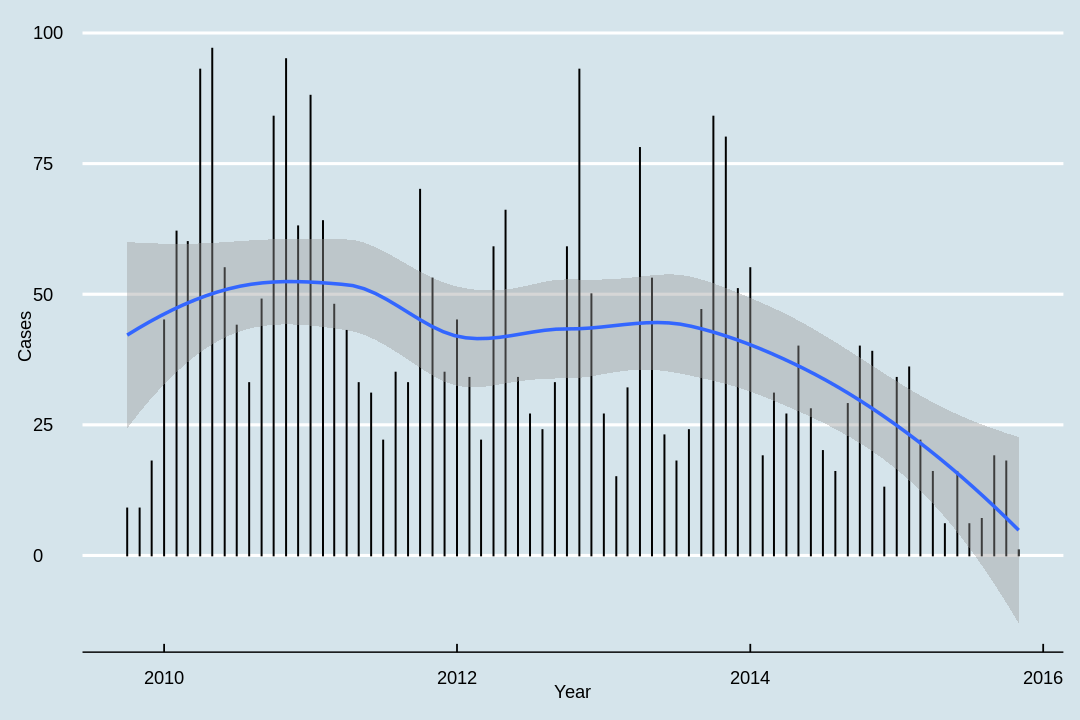

In [7]:
# Change plot size to 8 x 3
options(repr.plot.width=9, repr.plot.height=6)

ggplot(ParvoM, aes(x = byMonth, y = Events, group = 1)) +
  geom_bar(stat="identity", width = 0.5, colour = "black") +
  stat_smooth(aes(y = Events), method='auto', level=0.95) +
  theme_economist()  +
  scale_x_date() +
  xlab("Year") +
  ylab("Cases")



### Convert the data to an R recognised time-series

Here, we use the `ts` function from the stats package.

`frequency = 12` is specified because there are 12 weeks (sort of) in a year.

In [8]:
Parvo_ts_dataM <- ts(ParvoM$Events, start = c(2009, 10), frequency =12)

### Decomposition of the time-series data

The observed data is composed of trend, cycle, seasonal and random variation.
<br/><br/>
The function `decompose` is from the base package `stats`, and uses moving averages to smooth the time-series. We also demonstrate the function 'stl' from the stats package which uses loess smoothing.
<br/><br/>
The data are illustrated as follows:
<br/><br/>
Observed - the actual data.
<br/><br/>
Trend - the overall upward or downward movement of the data points. It is not necessarily linear.
<br/><br/>
Seasonal - any monthly/yearly pattern of the data points.
<br/><br/>
Random (remainder) - unexplainable part of the data.

### Moving averages

In [9]:
# Change plot size to 8 x 3
options(repr.plot.width=9, repr.plot.height=6)

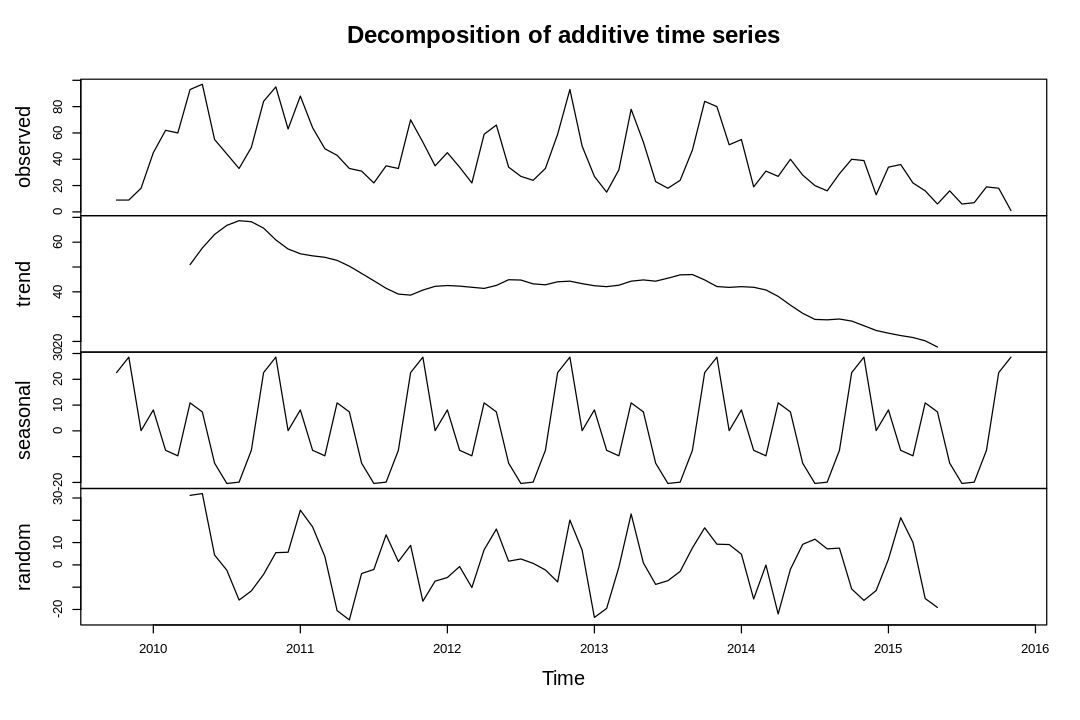

In [10]:
# Weekly ts dataset
Decompose_ts <- decompose(Parvo_ts_dataM)
#summary(Decompose_ts)
plot(Decompose_ts)

### SLT (loess)

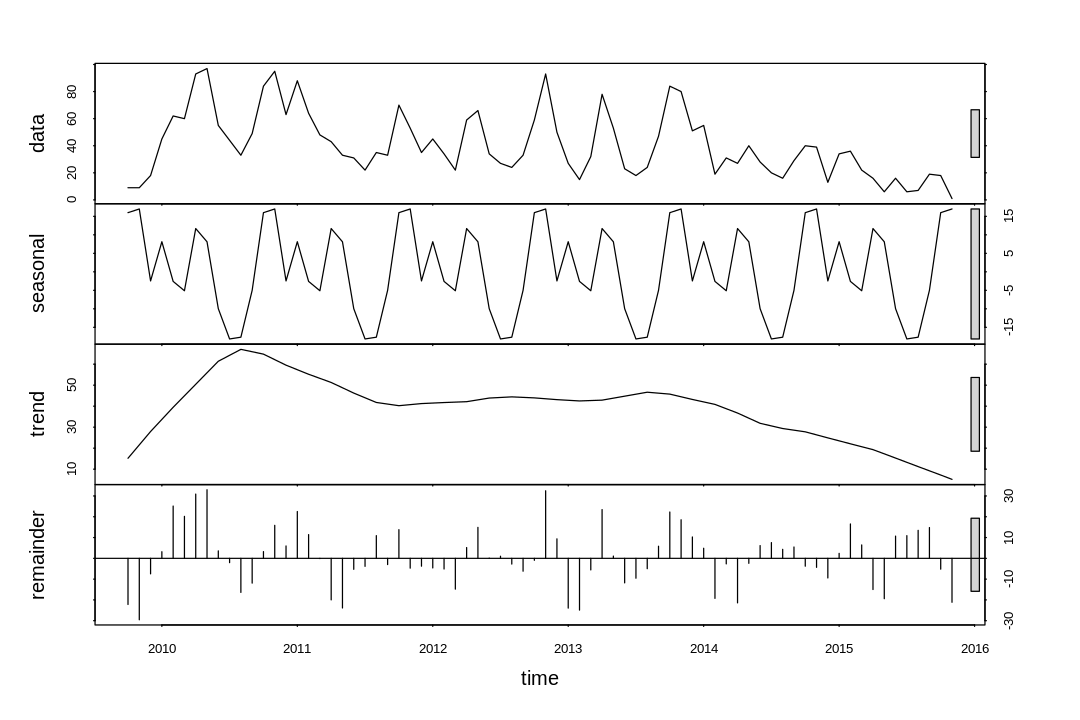

In [11]:
Decompose_ts_loess <- stl(Parvo_ts_dataM, s.window="periodic")
plot(Decompose_ts_loess)

### There looks like seasonality. Add a week and month column to ParvoW to investigate further

In [12]:
ParvoM$Year = year(ParvoM$byMonth)
ParvoM$Week = week(ParvoM$byMonth)
ParvoM$Month = month(ParvoM$byMonth)
head(ParvoM)

,byMonth,Cases,Events,Year,Week,Month
,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,2009-10-01,9,9,2009,40,10
2,2009-11-01,9,9,2009,44,11
3,2009-12-01,21,18,2009,48,12
4,2010-01-01,49,45,2010,1,1
5,2010-02-01,66,62,2010,5,2
6,2010-03-01,66,60,2010,9,3


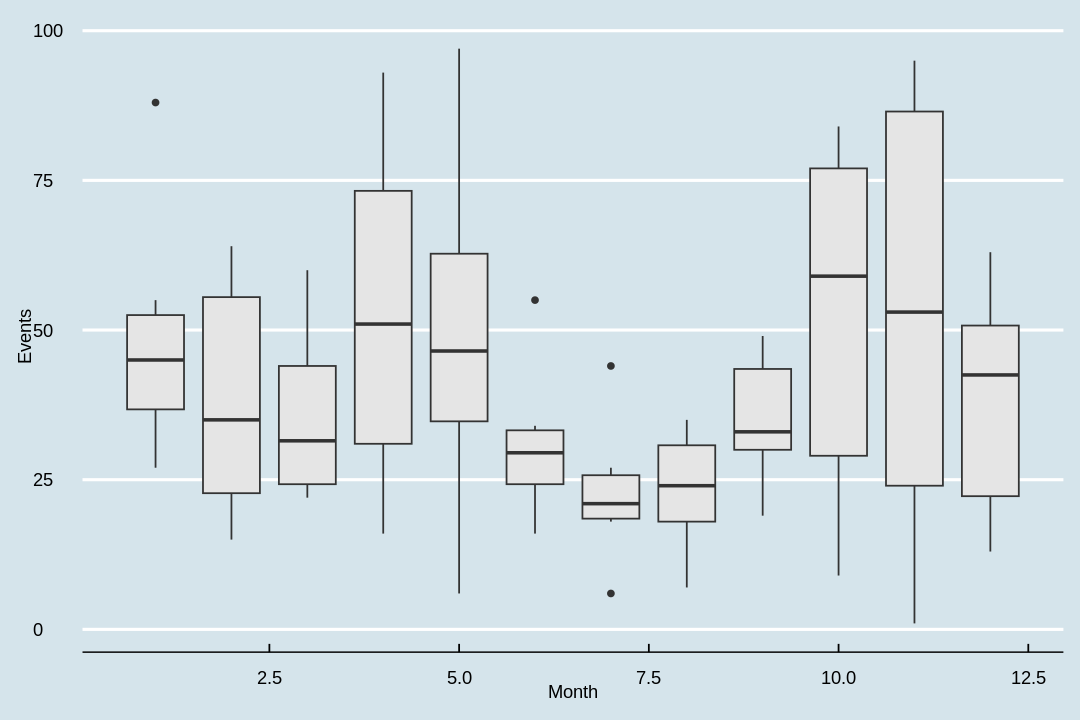

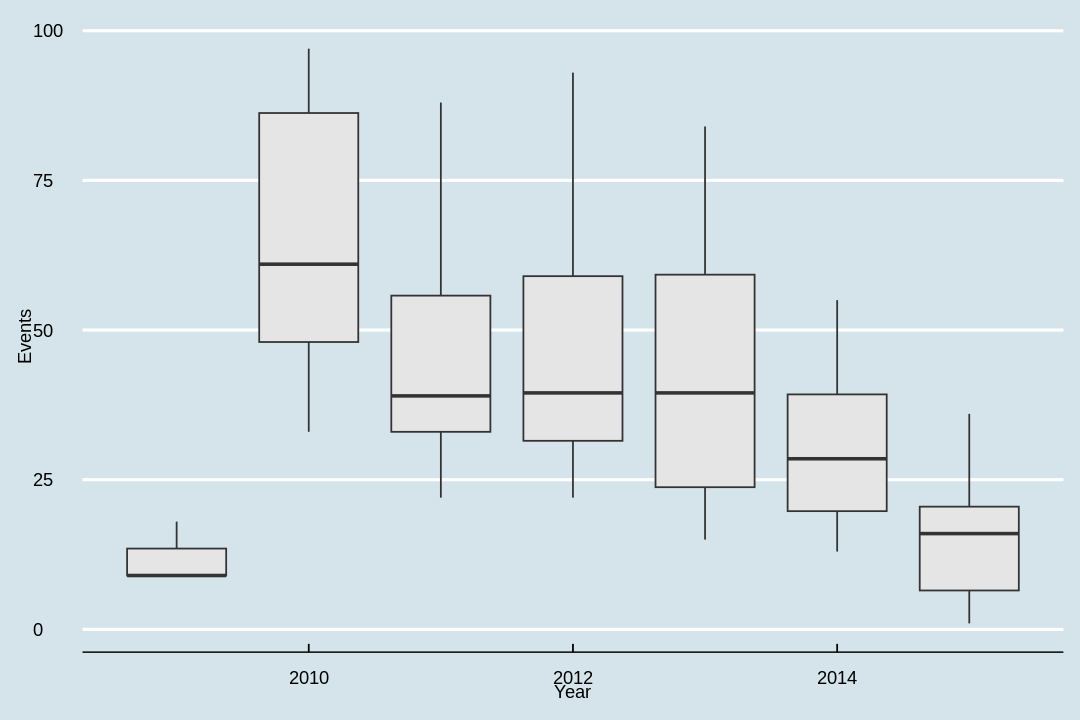

In [13]:
options(repr.plot.width=9, repr.plot.height=6)
ParvoM$Year = year(ParvoM$byMonth)
ParvoM$Week = week(ParvoM$byMonth)
ParvoM$Month = month(ParvoM$byMonth)

#ggplot(ParvoM, aes(y=Events, x = Week)) + geom_boxplot(aes(group=Week), fill = 'grey90') + theme_economist()
ggplot(ParvoM, aes(y=Events, x = Month)) + geom_boxplot(aes(group=Month), fill = 'grey90') + theme_economist()
ggplot(ParvoM, aes(y=Events, x = Year)) + geom_boxplot(aes(group=Year), fill = 'grey90') + theme_economist()

# Time-series analysis using autoregressive models
ARIMA is an abbreviation for 'AutoRegressive Integrated Moving Average'.
<br/><br/>
Refer to the presentation

### Test for stationarity

In [15]:
?ggtsdisplay

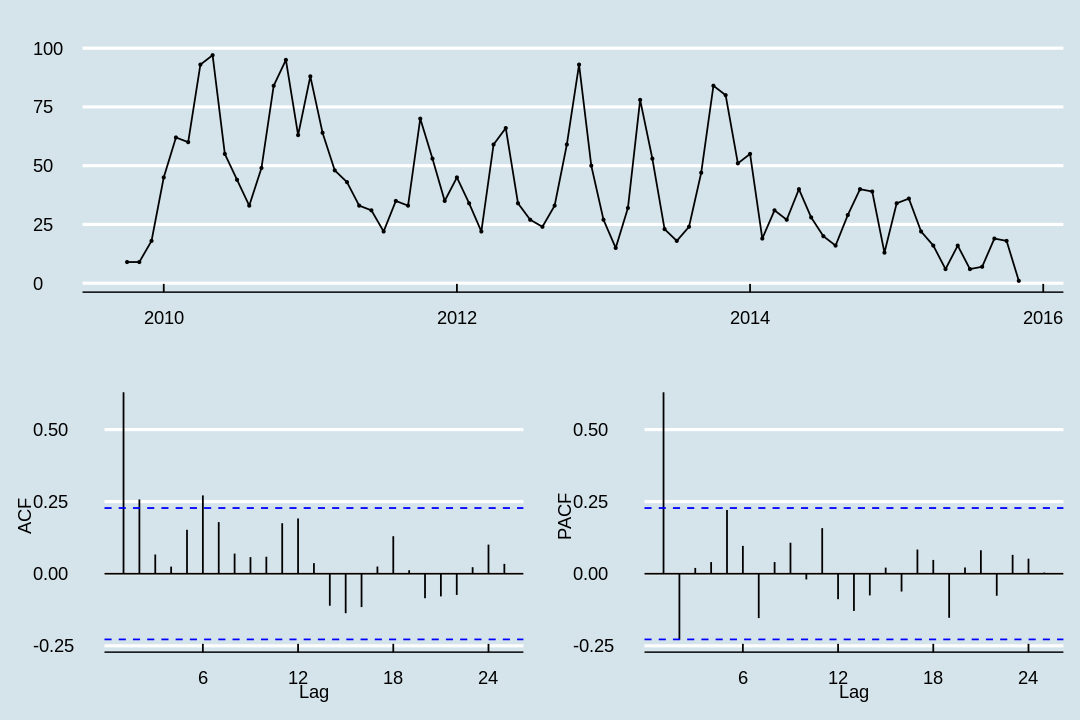

In [14]:
## Tests for stationarity
# Weekly data
Parvo_ts_dataM %>% ggtsdisplay(theme = theme_economist())

In [16]:
ndiffs(Parvo_ts_dataM) # 1 difference estimated to induce stationarity

[1] 1

In [19]:
?ndiffs

In [20]:
?nsdiffs

In [17]:
nsdiffs(Parvo_ts_dataM) # No differencing required to induce stationarity for seasonal component

[1] 0

We then run `ndiffs` from the `forecast` package to assess how many first differences are needed to induce stationarity. `ndiffs` suggests 1 first difference for each time series. After differencing the data, the time-series plots appears level (no trend) and the ACF plots show limited autocorrelation (one lag) in the first few lags.

In [22]:
?diff()

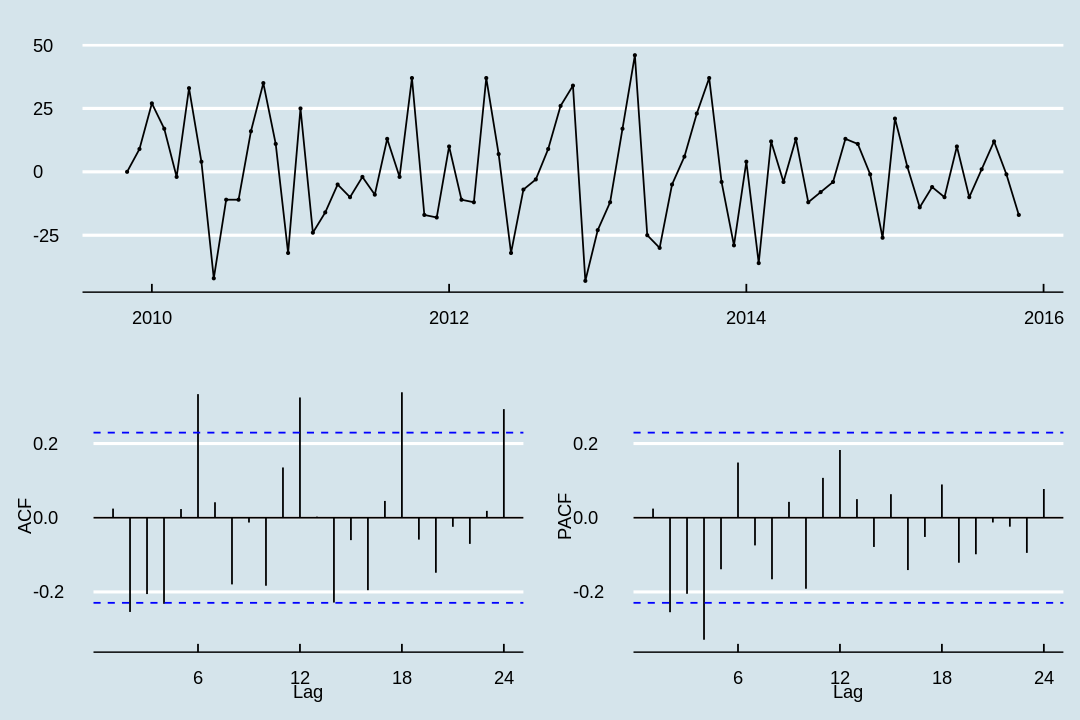

In [18]:
Parvo_ts_dataM %>% diff() %>% ggtsdisplay(theme = theme_economist()) # Assess differenced ts and ACF and PACF plots.

### We further check for stationarity in the time-series using statisical tests.

### Box-Ljung test
(Null hypothesis = time independance in a given period of lags. A low P value suggests that the data are not consistent with independance)

In [19]:
## Weekly time-series tests for stationarity
##
# 1.
Box.test(Parvo_ts_dataM, lag = 12, type="Ljung-Box")


	Box-Ljung test

data:  Parvo_ts_dataM
X-squared = 53.87, df = 12, p-value = 2.883e-07


### Augmented Dickey-Fuller Test

In [20]:
# 2.
adf.test(Parvo_ts_dataM, alternative = "stationary", k = 24)


	Augmented Dickey-Fuller Test

data:  Parvo_ts_dataM
Dickey-Fuller = -0.84262, Lag order = 24, p-value = 0.9536
alternative hypothesis: stationary


### KPSS test

In [21]:
# 3.
kpss.test(Parvo_ts_dataM, null = 'Trend') # The null hypothesis is a time trend with stationary error.
kpss.test(Parvo_ts_dataM, null = 'Level') # The null hypothesis is that the series is white noise.

Warning message in kpss.test(Parvo_ts_dataM, null = "Trend"):
“p-value greater than printed p-value”



	KPSS Test for Trend Stationarity

data:  Parvo_ts_dataM
KPSS Trend = 0.086265, Truncation lag parameter = 3, p-value = 0.1



	KPSS Test for Level Stationarity

data:  Parvo_ts_dataM
KPSS Level = 0.71758, Truncation lag parameter = 3, p-value = 0.01195


### Difference the Time-Series and retest the data for Stationarity

In [22]:
## Weekly time-series tests for stationarity
# 1.
Box.test(diff(Parvo_ts_dataM), lag=12, type="Ljung-Box")


	Box-Ljung test

data:  diff(Parvo_ts_dataM)
X-squared = 38.561, df = 12, p-value = 0.0001243


In [23]:
# 2.
adf.test(diff(Parvo_ts_dataM), alternative = "stationary", k = 24)


	Augmented Dickey-Fuller Test

data:  diff(Parvo_ts_dataM)
Dickey-Fuller = -1.9387, Lag order = 24, p-value = 0.6003
alternative hypothesis: stationary


In [24]:
# 3.
kpss.test(diff(Parvo_ts_dataM), null = 'Trend') # The null hypothesis is a time trend with stationary error.
kpss.test(diff(Parvo_ts_dataM), null = 'Level') # The null hypothesis is that the series is white noise.

Warning message in kpss.test(diff(Parvo_ts_dataM), null = "Trend"):
“p-value greater than printed p-value”



	KPSS Test for Trend Stationarity

data:  diff(Parvo_ts_dataM)
KPSS Trend = 0.032465, Truncation lag parameter = 3, p-value = 0.1


Warning message in kpss.test(diff(Parvo_ts_dataM), null = "Level"):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  diff(Parvo_ts_dataM)
KPSS Level = 0.091647, Truncation lag parameter = 3, p-value = 0.1


### Interpreting ACF and PACF plots to determine p, d, P and D.

From our tests of stationarity, we know that 'd' in the non-seasonal part of the ARIMA model is likely to be 1, and 'D' in the seasonal part of the model is likely to be zero.
<br/><br/>
We now use the ACF and PACF plots of the differenced data to estimate the p and q values in the non-seasonal section of the ARIMA model.

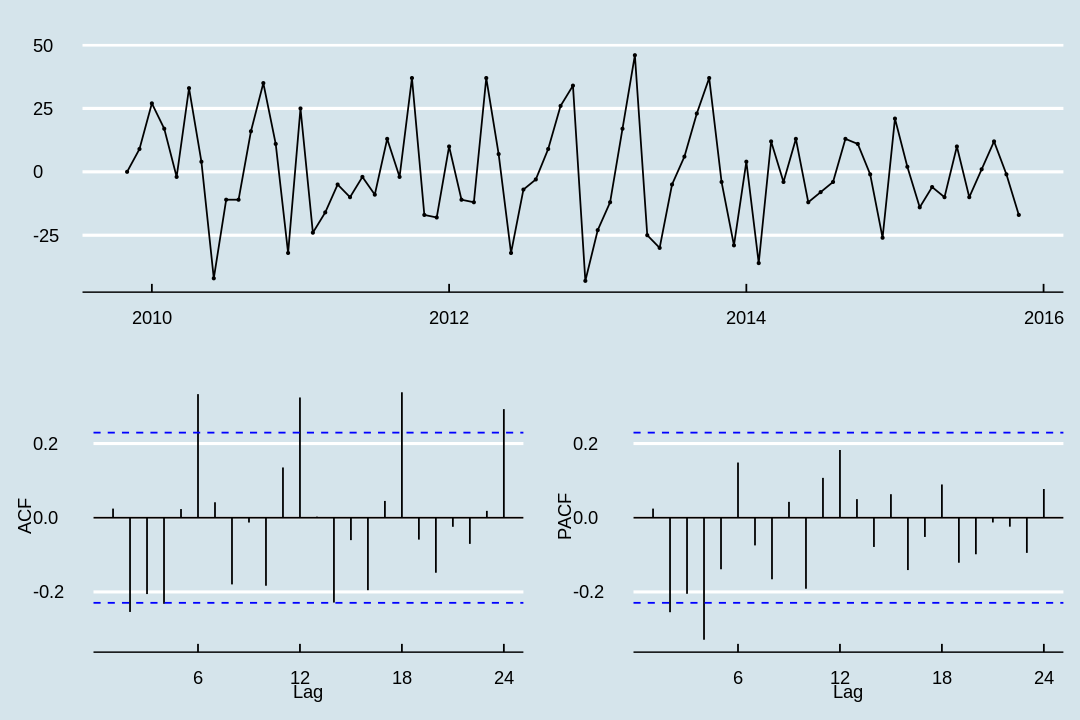

In [25]:
# Weekly data
Parvo_ts_dataM %>% diff() %>% ggtsdisplay(theme = theme_economist()) # Assess differenced ts and ACF and PACF plots.

### Determining Autocorrelation related parameters

The ACF plot of the weekly time series has a fast initial decay with only the first lag significant.
<br/><br/>
This indicates MA(1) for the weekly ARIMA model.

The PACF plot for the weekly data has a fast decay with significant partial autocorrelation in the first two lags significant. <br/><br/>This suggests AR(2).

### Determining Seasonlity related parameters

For seasonality, there are spikes in the weekly ACF at approximately 2 years, indicating MA(1-3).
<br/><br/>
There are 3 spikes around 6 months in the PACF, indicating AR(1-3).

## 2. Fit an ARIMA model

An ARIMA model with a seasonal component can be called a SARIMA model.

Based on exploratory analysis, we expect that the structure is:

Weekly ARIMA: (2, 1, 1) (1-3, 0, 1-3) [52]

In [26]:
?auto.arima

Initially we will use an automated function `auto.arima` to determine the model structure. This will run very slowly if all models are tested.
<br/><br/>
We then fit other plausible models based on the exploratory analysis. We select the final model based on lowest AIC.

In [27]:
Auto_Arima = auto.arima(Parvo_ts_dataM)
summary(Auto_Arima)

Series: Parvo_ts_dataM 
ARIMA(2,1,1)(2,0,0)[12] 

Coefficients:
         ar1      ar2      ma1    sar1    sar2
      0.7976  -0.2931  -0.9028  0.1562  0.2939
s.e.  0.1445   0.1349   0.1120  0.1241  0.1361

sigma^2 = 289.2:  log likelihood = -309.67
AIC=631.33   AICc=632.61   BIC=645.08

Training set error measures:
                     ME     RMSE      MAE       MPE     MAPE      MASE
Training set -0.8649256 16.30082 13.35613 -43.75883 66.48852 0.6088825
                  ACF1
Training set -0.016731

In [35]:
#Auto_Arima2 = auto.arima(Parvo_ts_data, stepwise = FALSE)
#summary(Auto_Arima2)

The automated function has slected a model with structure ARIMA(2,1,1)(2,0,0)[12]

Series: Parvo_ts_dataM 
ARIMA(2,1,1)(2,0,0)[12] 

Coefficients:
         ar1      ar2      ma1    sar1    sar2
      0.7976  -0.2931  -0.9028  0.1562  0.2939
s.e.  0.1445   0.1349   0.1120  0.1241  0.1361

sigma^2 = 289.2:  log likelihood = -309.67
AIC=631.33   AICc=632.61   BIC=645.08

Training set error measures:
                     ME     RMSE      MAE       MPE     MAPE      MASE
Training set -0.8649256 16.30082 13.35613 -43.75883 66.48852 0.6088825
                  ACF1
Training set -0.016731
           2.5 %      97.5 %
ar1   0.51445880  1.08072577
ar2  -0.55744930 -0.02881159
ma1  -1.12243907 -0.68326091
sar1 -0.08702875  0.39948777
sar2  0.02719193  0.56070415


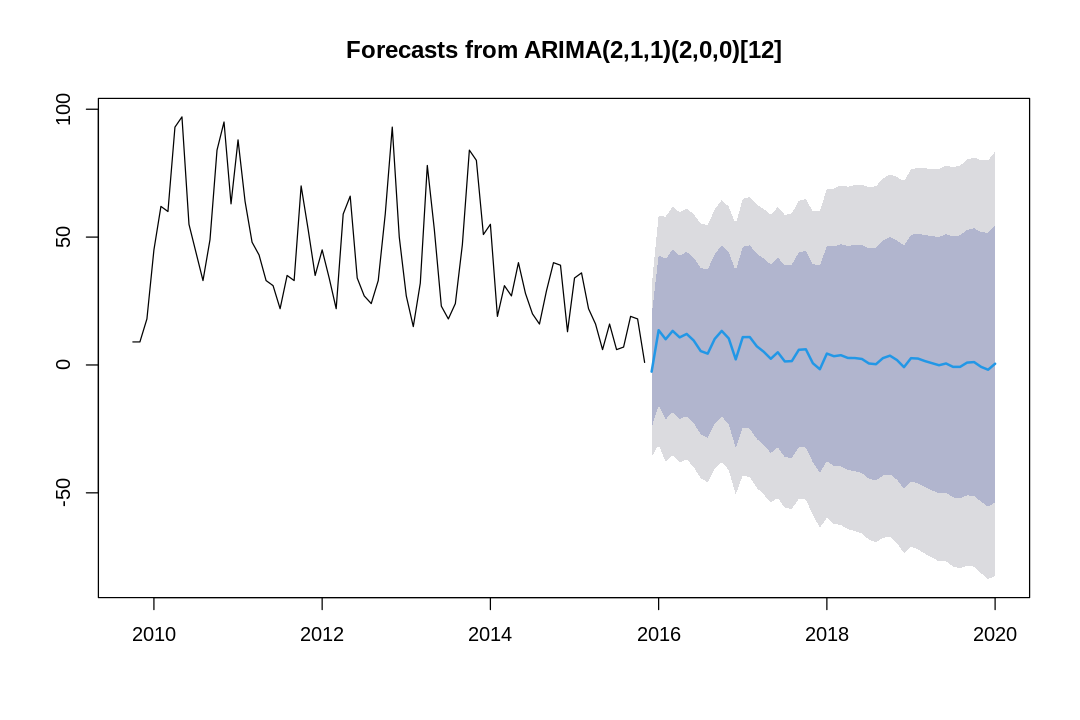


	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)(2,0,0)[12]
Q* = 9.0685, df = 10, p-value = 0.5256

Model df: 5.   Total lags used: 15


	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)(2,0,0)[12]
Q* = 9.0685, df = 10, p-value = 0.5256



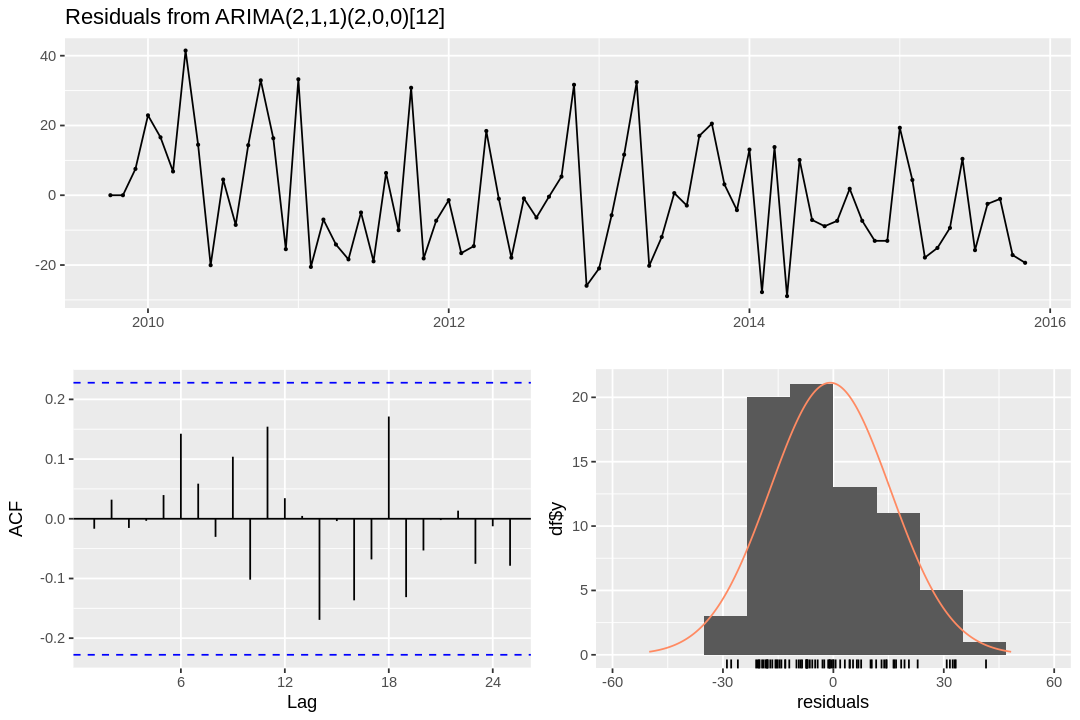

In [28]:
plot(forecast(Auto_Arima, 50))
print(summary(Auto_Arima))
print(confint(Auto_Arima))
print(checkresiduals(Auto_Arima))

#### We will test other simple model structures which are still within the estimated parameters from the the time series exploration

In [29]:
fit1 = Arima(Parvo_ts_dataM, order = c(1, 1, 1), seasonal = c(1, 0, 0))
fit2 = Arima(Parvo_ts_dataM, order = c(2, 1, 1), seasonal = c(0, 0, 1))
fit3 = Arima(Parvo_ts_dataM, order = c(2, 1, 1), seasonal = c(2, 0, 0), include.drift = T)
fit4 = Arima(Parvo_ts_dataM, order = c(1, 1, 0), seasonal = c(1, 0, 0))

In [30]:
AIC(fit1, fit2, fit3,fit4, Auto_Arima)

,df,AIC
,<dbl>,<dbl>
fit1,4,634.4702
fit2,5,634.8696
fit3,7,631.2898
fit4,3,640.6253
Auto_Arima,6,631.3333



	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)(2,0,0)[12] with drift
Q* = 9.2198, df = 10, p-value = 0.5114

Model df: 5.   Total lags used: 15


	Ljung-Box test

data:  Residuals from ARIMA(2,1,1)(2,0,0)[12] with drift
Q* = 9.2198, df = 10, p-value = 0.5114



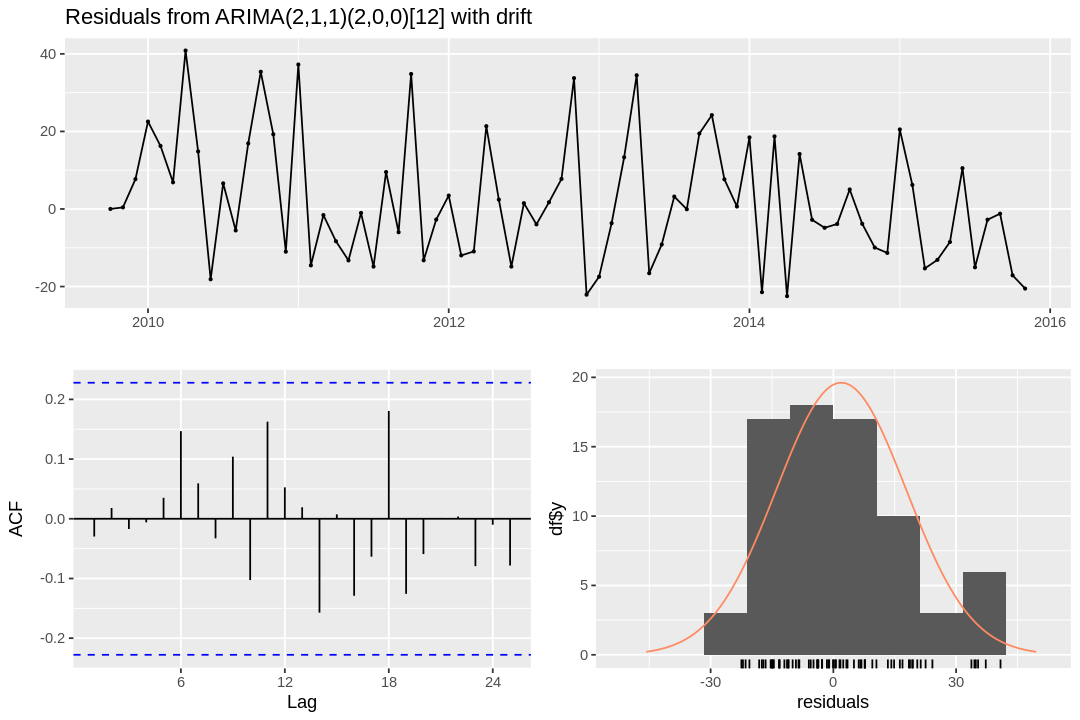

In [31]:
print(checkresiduals(fit3))

The final models are `fit3` for the weekly time-series and the auto-fitted model for the monthly time-series.
Each has the lowest AICc of tested models, and produces a plausible forecast of the original time series. The residuals are reasonably Normaly distributed and the ACF plot of the residuals and Ljung-Box tests suggest that the residuals are time independent.


# Section 1: Multivariate forecasting with time-series
In this section, we first consider how to modify an ARIMA model to include a predictor (other than the univariate time-series). We use the example of rainfall as a predictor of parvovirus events, and select monthly rainfall at Mudgee, NSW (mean centre of parvovirus event data).

#### Q1 : Complete the following steps to process rainfall data ready for modelling

#### Points 10

1. Read `Mudgee_Monthly_rainfall.csv` data file in R

In [32]:
RainfallM <- read.csv("/content/Mudgee_Monthly_rainfall.csv")
RainfallM$Date = as.character(RainfallM$Date, format = "%d/%m/%Y")

2. Convert the column for date as Date obeject in R (use appropriate date format)

In [33]:
RainfallM$Date = as.character(RainfallM$Date, format = "%d/%m/%Y")
RainfallM$Date = as.Date(RainfallM$Date, format = "%Y-%m-%d")

3. Create columns assigning a starting month date and starting week date to individual day and convert those columns as `as.Date` data type

In [34]:
RainfallM$byMonth = cut(RainfallM$Date, breaks = "1 month")
RainfallM$byMonth = as.Date(RainfallM$byMonth, format = "%Y-%m-%d")
RainfallM$byWeek  = cut(RainfallM$Date, breaks = "1 week")
RainfallM$byWeek  = as.Date(RainfallM$byWeek, format = "%Y-%m-%d")
head(RainfallM)

Warning message in min.default(structure(c(NA_real_, NA_real_, NA_real_, NA_real_, :
“no non-missing arguments to min; returning Inf”
Warning message in max.default(structure(c(NA_real_, NA_real_, NA_real_, NA_real_, :
“no non-missing arguments to max; returning -Inf”


ERROR: Error in seq.int(lres$mon, 12 * (lto$year - lres$year) + lto$mon, by): 'from' must be a finite number


In [35]:
head(RainfallM)

,Date,Rain_mm
,<date>,<dbl>
1,NA,34.0
2,NA,16.0
3,NA,121.4
4,NA,46.4
5,NA,90.0
6,NA,89.0


4. Create a plot showing daily rainfall (bargraph) and also show a trend line using `stat_smooth` function.
<br/><br/>
Is there a possible *trend* and *seasonlity* in the data?  

In [36]:
ggplot(RainfallM, aes(x = Date, y = Rainfall, group = 1)) +
  geom_bar(stat = "identity", width = 0.5, colour = "black") +
  stat_smooth(aes(y = Rainfall), method = 'auto', level = 0.95) +
  theme_economist() +
  scale_x_date() +
  xlab("Year") + ylab("Rainfall (mm)")

ERROR while rich displaying an object: Error in `geom_bar()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'Rainfall' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .

5. Create a timeseries object for the monthly rainfall using `ts` function.
<br/><br/>


In [37]:
Rainfall_ts_data <- ts(RainfallM$Rainfall,
                       start     = c(2009, 10),
                       frequency = 12)

ERROR: Error in ts(RainfallM$Rainfall, start = c(2009, 10), frequency = 12): 'ts' object must have one or more observations


In [38]:
head(RainfallM)
names(RainfallM)

,Date,Rain_mm
,<date>,<dbl>
1,NA,34.0
2,NA,16.0
3,NA,121.4
4,NA,46.4
5,NA,90.0
6,NA,89.0


[1] "Date"    "Rain_mm"

In [39]:
RainfallM_raw <- read.csv("/content/Mudgee_Monthly_rainfall.csv")
head(RainfallM_raw)

,Date,Rain_mm
,<chr>,<dbl>
1,1/10/2009,34.0
2,1/11/2009,16.0
3,1/12/2009,121.4
4,1/01/2010,46.4
5,1/02/2010,90.0
6,1/03/2010,89.0


In [40]:
RainfallM <- read.csv("/content/Mudgee_Monthly_rainfall.csv")

# Fix date conversion - format matches "1/12/2009"
RainfallM$Date <- as.Date(RainfallM$Date, format = "%d/%m/%Y")

# Create month and week columns
RainfallM$byMonth <- cut(RainfallM$Date, breaks = "1 month")
RainfallM$byMonth <- as.Date(RainfallM$byMonth, format = "%Y-%m-%d")
RainfallM$byWeek  <- cut(RainfallM$Date, breaks = "1 week")
RainfallM$byWeek  <- as.Date(RainfallM$byWeek, format = "%Y-%m-%d")

head(RainfallM)

,Date,Rain_mm,byMonth,byWeek
,<date>,<dbl>,<date>,<date>
1,2009-10-01,34.0,2009-10-01,2009-09-28
2,2009-11-01,16.0,2009-11-01,2009-10-26
3,2009-12-01,121.4,2009-12-01,2009-11-30
4,2010-01-01,46.4,2010-01-01,2009-12-28
5,2010-02-01,90.0,2010-02-01,2010-02-01
6,2010-03-01,89.0,2010-03-01,2010-03-01


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


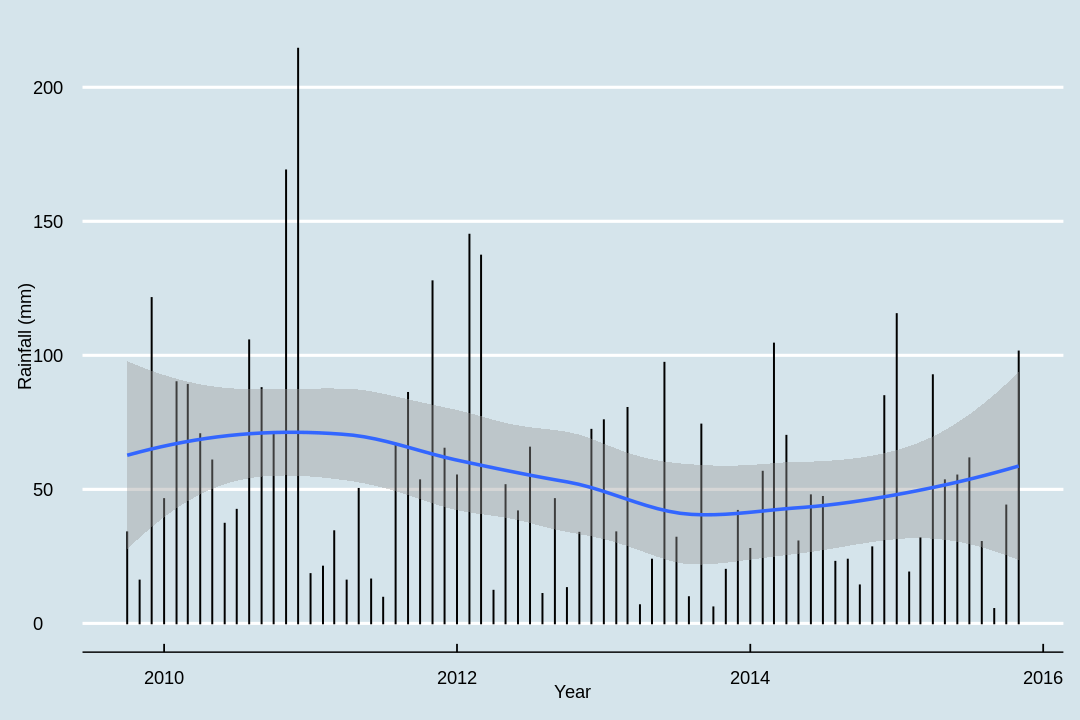

In [41]:
# Plot
ggplot(RainfallM, aes(x = Date, y = Rain_mm, group = 1)) +
  geom_bar(stat = "identity", width = 0.5, colour = "black") +
  stat_smooth(aes(y = Rain_mm), method = 'auto', level = 0.95) +
  theme_economist() +
  scale_x_date() +
  xlab("Year") + ylab("Rainfall (mm)")

# ts object - check what year/month row 1 actually is first
Rainfall_ts_data <- ts(RainfallM$Rain_mm, start = c(2009, 10), frequency = 12)

### Q2 Check for trend and seasonlity in the rainfall data by decomposing the time-series
What are your interpretations around trend and seasonlity?
* You can use one of the two methods shown in the class (`moving averages`/`slt`)


#### Points 5

ANSWER:

Trend begins around 74 mm in 2010, and peaks to 90 mm before dropping to about 40 mm by 2013. It then slightly increases to 50 mm by 2016. Overall, the trend is deceasing in monthly rainfall during the time period. This means it was getting drier over the years.

Regarding seasonality, there is a pattern that repeats what looks like every year. There are peaks of about 30 mm and lesser peakd at 20 amm and 5 mm, showing consistency in seasonal rainfall.

         Length Class  Mode     
x        74     ts     numeric  
seasonal 74     ts     numeric  
trend    74     ts     numeric  
random   74     ts     numeric  
figure   12     -none- numeric  
type      1     -none- character

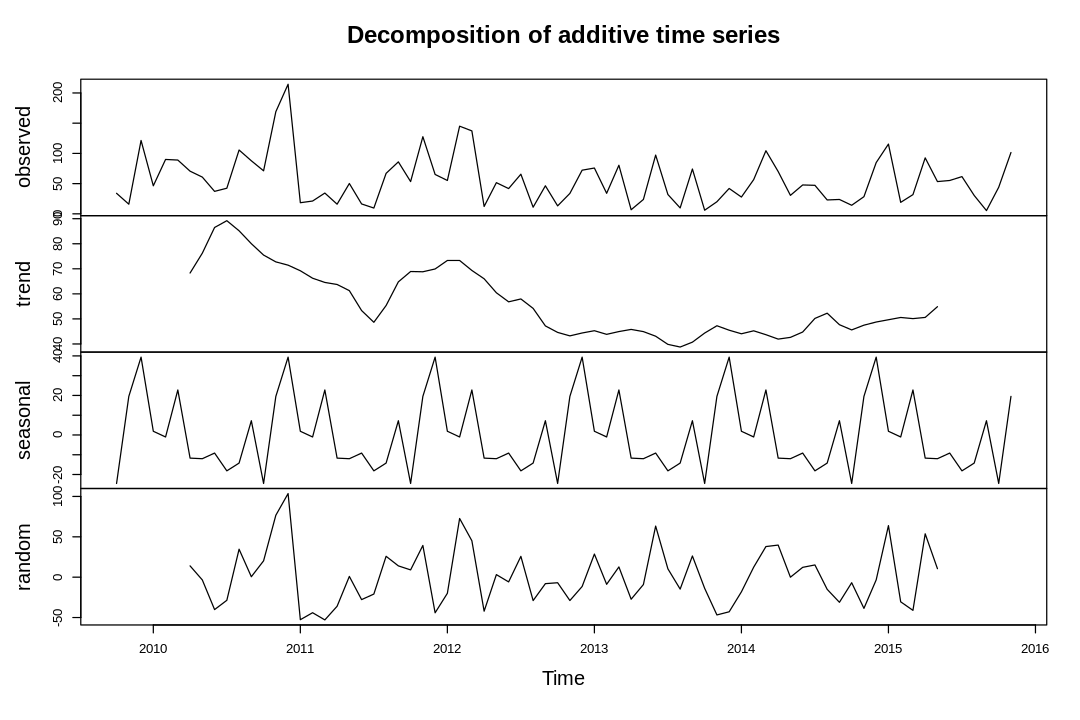

In [42]:
Decompose_tsRainM <- decompose(Rainfall_ts_data)
summary(Decompose_tsRainM)
plot(Decompose_tsRainM)

 Call:
 stl(x = Rainfall_ts_data, s.window = "periodic")

 Time.series components:
    seasonal             trend         remainder       
 Min.   :-21.63659   Min.   :40.63   Min.   :-52.1192  
 1st Qu.:-13.61638   1st Qu.:45.41   1st Qu.:-24.8248  
 Median : -5.65074   Median :53.86   Median : -1.1458  
 Mean   : -0.09299   Mean   :56.25   Mean   :  0.3005  
 3rd Qu.: 12.19173   3rd Qu.:65.04   3rd Qu.: 21.4335  
 Max.   : 44.48094   Max.   :85.59   Max.   : 96.6453  
 IQR:
     STL.seasonal STL.trend STL.remainder data 
     25.81        19.62     46.26         50.60
   %  51.0         38.8      91.4         100.0

 Weights: all == 1

 Other components: List of 5
 $ win  : Named num [1:3] 741 19 13
 $ deg  : Named int [1:3] 0 1 1
 $ jump : Named num [1:3] 75 2 2
 $ inner: int 2
 $ outer: int 0


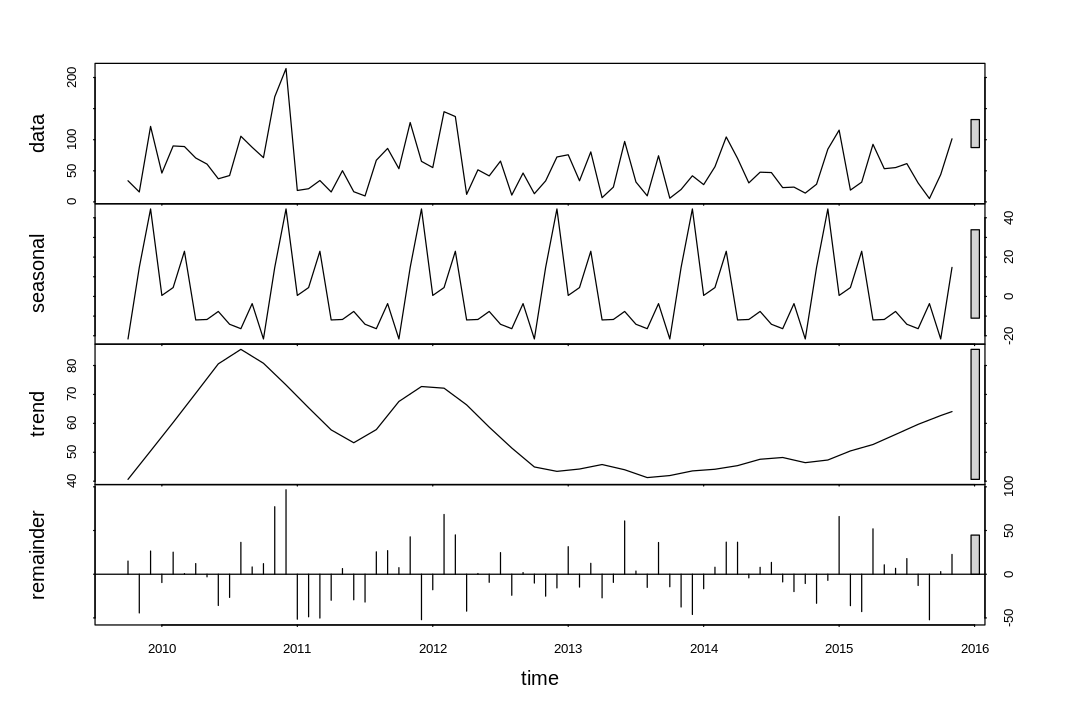

In [43]:
Decompose_tsRainM <- stl(Rainfall_ts_data, s.window = "periodic")
summary(Decompose_tsRainM)
plot(Decompose_tsRainM)

### Q3 Check for stationarity of the data
Q3a. Use `ndiffs` and `nsdiff` fromt the `forecast` package to assess how many first differences are needed to induce stationarity. Report those numbers.
<br/><br/>
Q3B. Run three statistical tests for stationarity
<br/><br/>
Q3C. Based on these results (Q2 and Q3 combined), do you think there is evidence of trend and seasonality of monthly rainfall in Mudgee? And is the data stationary?

#### Points 10

ANSWERS:

3a) 0 and 0

3c) Based on decomposition, rainfall shows a downward trend from 2010-2014 and consistent repeating seasonal pattern every year. The stationary tests support this with ADF test with p= 0.99 failed to reject non-stationary. ndiffs confrimed the differences needed to induce stationary. nsdiffs=0 indicated no seasonal difference is required. Box-Ljung with p=0.098 and KPSS test with p=0.1 were non-signifcant.

In [44]:
ndiffs(Rainfall_ts_data)   # how many first-differences needed
nsdiffs(Rainfall_ts_data)  # how many seasonal differences needed


[1] 0

[1] 0

In [45]:
# 1. Box-Ljung test (null = independence / no autocorrelation)
Box.test(Rainfall_ts_data, lag = 12, type = "Ljung-Box")

# 2. Augmented Dickey-Fuller (null = non-stationary)
adf.test(Rainfall_ts_data, alternative = "stationary", k = 24)

# 3. KPSS tests (null = stationary)
kpss.test(Rainfall_ts_data, null = 'Trend')
kpss.test(Rainfall_ts_data, null = 'Level')


	Box-Ljung test

data:  Rainfall_ts_data
X-squared = 18.627, df = 12, p-value = 0.09794


Warning message in adf.test(Rainfall_ts_data, alternative = "stationary", k = 24):
“p-value greater than printed p-value”



	Augmented Dickey-Fuller Test

data:  Rainfall_ts_data
Dickey-Fuller = -0.071898, Lag order = 24, p-value = 0.99
alternative hypothesis: stationary


Warning message in kpss.test(Rainfall_ts_data, null = "Trend"):
“p-value greater than printed p-value”



	KPSS Test for Trend Stationarity

data:  Rainfall_ts_data
KPSS Trend = 0.052388, Truncation lag parameter = 3, p-value = 0.1


Warning message in kpss.test(Rainfall_ts_data, null = "Level"):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  Rainfall_ts_data
KPSS Level = 0.30441, Truncation lag parameter = 3, p-value = 0.1


# Section 4: ARIMA model with Rainfall as covariate

#### This section is for demonstration purposes only
#### Run this ARIMA model with Rainfall as explinatory variable and submit the outputs as shown in during the demonstration  

#### Points 5

#### Make a matrix of lagged predictors (0, 1, 2 or 3 lags).

In [46]:
RainLag <- cbind(
    AdLag0 = Rainfall_ts_data,
    AdLag1 = stats::lag(Rainfall_ts_data, k = 1),
    AdLag2 = stats::lag(Rainfall_ts_data, k = 2),
    AdLag3 = stats::lag(Rainfall_ts_data, k = 3)) %>%
  head(NROW(Rainfall_ts_data))



In [47]:
RainLag

,AdLag0,AdLag1,AdLag2,AdLag3
Jul 2009,NA,NA,NA,34.00
Aug 2009,NA,NA,34.00,16.00
Sep 2009,NA,34.00,16.00,121.40
Oct 2009,34.00,16.00,121.40,46.40
Nov 2009,16.00,121.40,46.40,90.00
Dec 2009,121.40,46.40,90.00,89.00
Jan 2010,46.40,90.00,89.00,70.60
Feb 2010,90.00,89.00,70.60,60.80
Mar 2010,89.00,70.60,60.80,37.20
Apr 2010,70.60,60.80,37.20,42.40


#### Restrict data so models use same fitting period

In [48]:
fit1 <- auto.arima(Parvo_ts_dataM[4:70], xreg=RainLag[4:70,1])
fit2 <- auto.arima(Parvo_ts_dataM[4:70], xreg=RainLag[4:70,1:2])
fit3 <- auto.arima(Parvo_ts_dataM[4:70], xreg=RainLag[4:70,1:3])
fit4 <- auto.arima(Parvo_ts_dataM[4:70], xreg=RainLag[4:70,1:4])

In [49]:
c(fit1[["aicc"]],fit2[["aicc"]],fit3[["aicc"]],fit4[["aicc"]])

[1] 589.1365 584.9810 586.0320 585.4477

Series: Parvo_ts_dataM 
Regression with ARIMA(0,1,0)(0,0,2)[12] errors 

Coefficients:
        sma1    sma2  AdLag0  AdLag1  AdLag2
      0.0862  0.4990  0.0957  0.1886  0.1186
s.e.  0.1432  0.2115  0.0525  0.0502  0.0540

sigma^2 = 275.6:  log likelihood = -298.37
AIC=608.73   AICc=610.07   BIC=622.22

Training set error measures:
                     ME     RMSE      MAE      MPE    MAPE     MASE        ACF1
Training set -0.6847001 16.24539 12.63194 -28.4403 54.7225 0.575868 0.001659539

,2.5 %,97.5 %
sma1,-0.194470125,0.3669198
sma2,0.084559741,0.9134938
AdLag0,-0.007165825,0.1985386
AdLag1,0.090110552,0.2870869
AdLag2,0.012724438,0.2243913



	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,0)(0,0,2)[12] errors
Q* = 36.086, df = 13, p-value = 0.0005753

Model df: 2.   Total lags used: 15



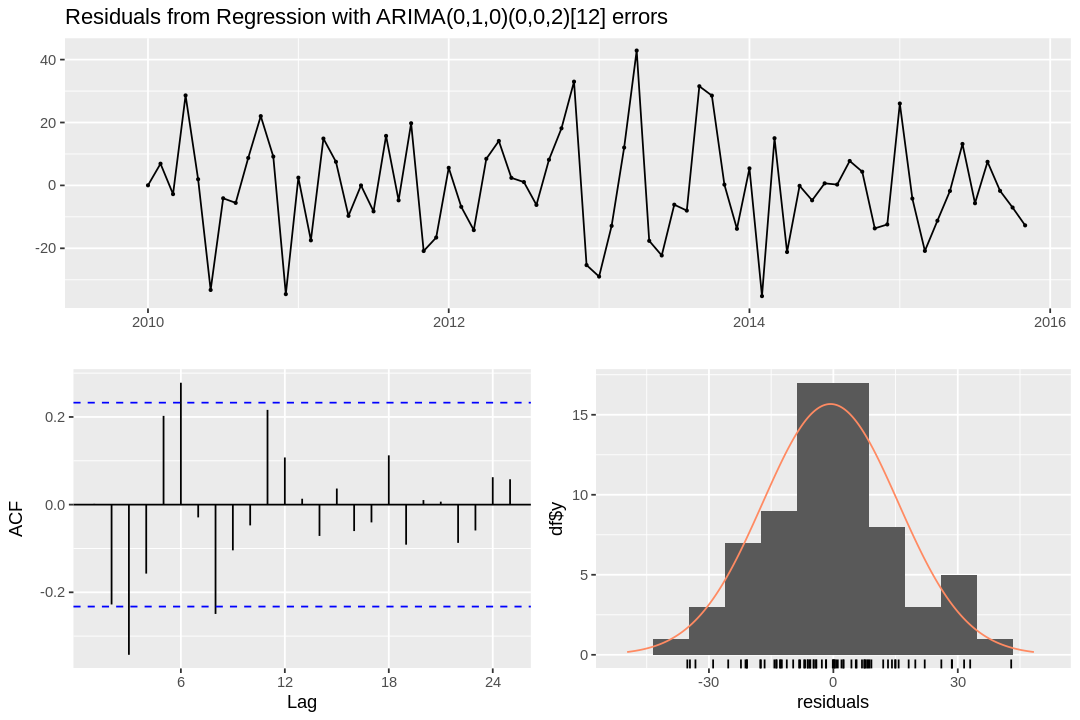

In [50]:
fit <- auto.arima(Parvo_ts_dataM, xreg=RainLag[,1:3])
summary(fit)
confint(fit)
checkresiduals(fit)



In [51]:
RainLag[,1:4]

,AdLag0,AdLag1,AdLag2,AdLag3
Jul 2009,NA,NA,NA,34.00
Aug 2009,NA,NA,34.00,16.00
Sep 2009,NA,34.00,16.00,121.40
Oct 2009,34.00,16.00,121.40,46.40
Nov 2009,16.00,121.40,46.40,90.00
Dec 2009,121.40,46.40,90.00,89.00
Jan 2010,46.40,90.00,89.00,70.60
Feb 2010,90.00,89.00,70.60,60.80
Mar 2010,89.00,70.60,60.80,37.20
Apr 2010,70.60,60.80,37.20,42.40


#### We then sequentially fir all rainfall lagged data to the best fitting monthly model from the previous section (all tested lags not shown here). The final model includes 3 months of lag and has the lowest AIC of all the models.


Series: Parvo_ts_dataM 
Regression with ARIMA(2,1,1)(2,0,0)[12] errors 

Coefficients:
         ar1      ar2      ma1    sar1    sar2  AdLag0  AdLag1  AdLag2   AdLag3
      0.5790  -0.3191  -0.7898  0.1714  0.4311  0.0731  0.1244  0.0574  -0.0974
s.e.  0.1431   0.1244   0.0985  0.1121  0.1237  0.0424  0.0434  0.0451   0.0425

sigma^2 = 215:  log likelihood = -285.91
AIC=591.82   AICc=595.55   BIC=614.31

Training set error measures:
                    ME     RMSE      MAE       MPE    MAPE      MASE
Training set -1.428161 13.59099 10.99478 -33.33115 51.2069 0.5012324
                    ACF1
Training set -0.07104356
             2.5 %      97.5 %
ar1     0.29864506  0.85941558
ar2    -0.56293394 -0.07532500
ma1    -0.98275398 -0.59683570
sar1   -0.04839783  0.39115861
sar2    0.18871048  0.67346830
AdLag0 -0.01005359  0.15625926
AdLag1  0.03931046  0.20949230
AdLag2 -0.03097413  0.14578449
AdLag3 -0.18055725 -0.01415212

	Ljung-Box test

data:  Residuals from Regression with ARIMA(2,1

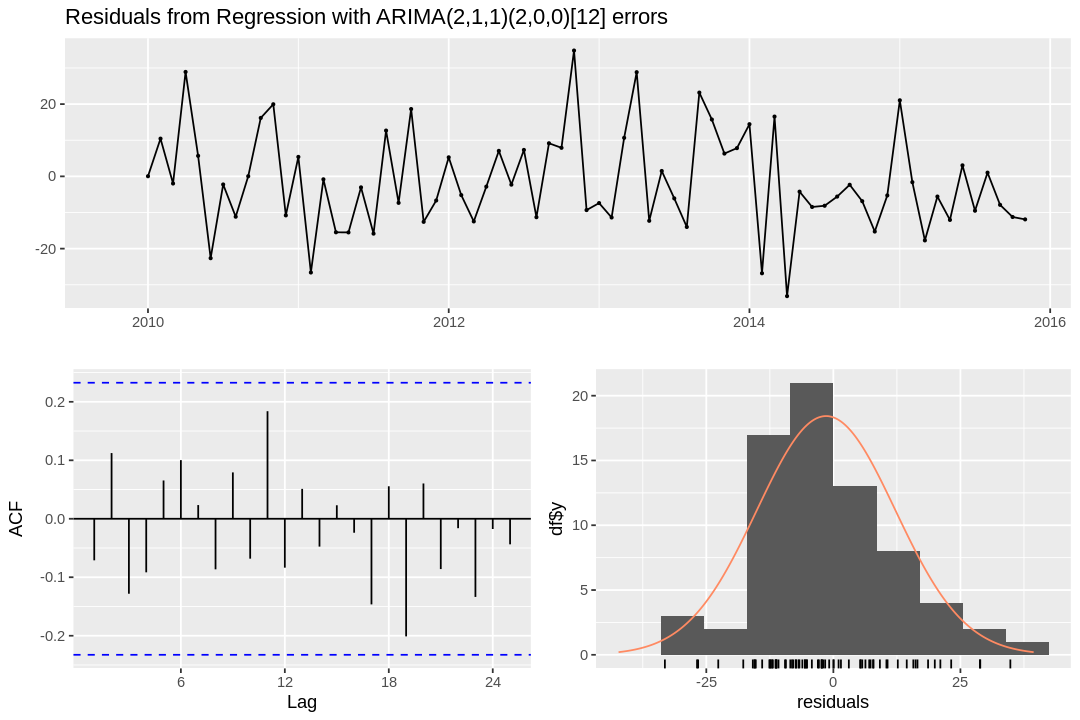

In [52]:
fitA <- Arima(Parvo_ts_dataM, order = c(2, 1, 1), seasonal = c(2, 0, 0), xreg=RainLag[,1:4])
print(summary(fitA))
print(confint(fitA))
print(checkresiduals(fitA))



#### We use the last fitted model for forecasting. The forecast is fitted with trimmed data otherwise error message: 'Upper prediction intervals are not finite.' due to NAs in lagged rainfall data.

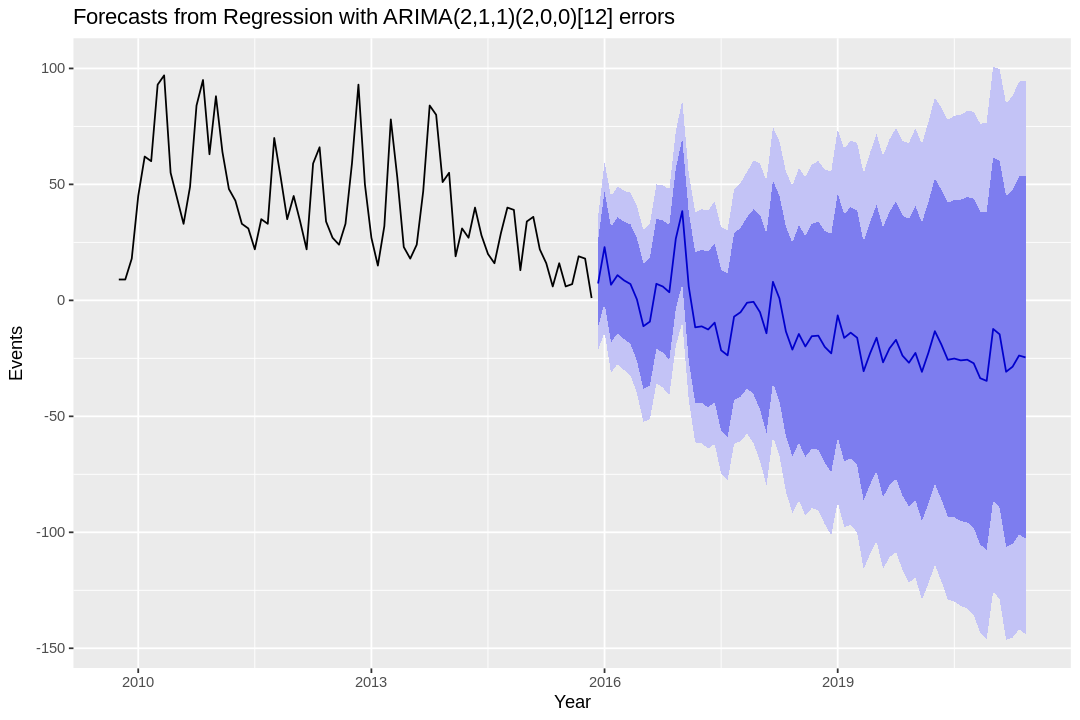

In [53]:
fcast <- forecast(fitA, h = 20, xreg=RainLag[4:70,1:4])
autoplot(fcast) + xlab("Year") + ylab("Events")

* An increase in rainfall in the previous month,
* possibly an increase in the month before that,
* and lower rainfall in month prior to that,
* could be associated with an increase in parvo events in the current month.
* This model has a lower AICc (595.55) than the model without rainfall as a predictor (AICc = 632.61). The forecast plot confidence intervals are still wide.
